In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



In [ ]:
df=pd.read_csv(r"C:\Users\waniu\Desktop\2026\diseaseheart.csv")
df=pd.read_csv(r"C:\Users\waniu\Desktop\2026\2026\diseaseheart.csv")


In [54]:
df.head(5)
#df.tail(5)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [7]:
df.describe(include='all')

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
count,918.000000,918,918,918.000000,918.000000,918.000000,918,918.000000,918,918.000000,918,918.000000
unique,NaN,2,4,NaN,NaN,NaN,3,NaN,2,NaN,3,NaN
top,NaN,M,ASY,NaN,NaN,NaN,Normal,NaN,N,NaN,Flat,NaN
freq,NaN,725,496,NaN,NaN,NaN,552,NaN,547,NaN,460,NaN
mean,53.510893,NaN,NaN,132.396514,198.799564,0.233115,NaN,136.809368,NaN,0.887364,NaN,0.553377
std,9.432617,NaN,NaN,18.514154,109.384145,0.423046,NaN,25.460334,NaN,1.066570,NaN,0.497414
min,28.000000,NaN,NaN,0.000000,0.000000,0.000000,NaN,60.000000,NaN,-2.600000,NaN,0.000000
25%,47.000000,NaN,NaN,120.000000,173.250000,0.000000,NaN,120.000000,NaN,0.000000,NaN,0.000000
50%,54.000000,NaN,NaN,130.000000,223.000000,0.000000,NaN,138.000000,NaN,0.600000,NaN,1.000000
75%,60.000000,NaN,NaN,140.000000,267.000000,0.000000,NaN,156.000000,NaN,1.500000,NaN,1.000000


In [8]:
#checking null values
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [9]:
#checking presence of duplicate records
df.duplicated().sum()

np.int64(0)

In [10]:
df.select_dtypes(include=['object']).columns

Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object')

In [11]:
from sklearn.preprocessing import LabelEncoder

# Binary encoding
df['Sex'] = LabelEncoder().fit_transform(df['Sex'])
df['ExerciseAngina'] = LabelEncoder().fit_transform(df['ExerciseAngina'])

# One-Hot Encoding
df = pd.get_dummies(
    df,
    columns=['ChestPainType', 'RestingECG', 'ST_Slope'],
    drop_first=True   
)

In [12]:
"""from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Label Encode binary categorical features if they are still 'object' type
if 'Sex' in df.columns and df['Sex'].dtype == 'object':
    df['Sex'] = le.fit_transform(df['Sex'])

if 'ExerciseAngina' in df.columns and df['ExerciseAngina'].dtype == 'object':
    df['ExerciseAngina'] = le.fit_transform(df['ExerciseAngina'])

# One-Hot Encode multi-category nominal features if they are still present
cols_to_dummies = []
if 'ChestPainType' in df.columns:
    cols_to_dummies.append('ChestPainType')
if 'RestingECG' in df.columns:
    cols_to_dummies.append('RestingECG')
if 'ST_Slope' in df.columns:
    cols_to_dummies.append('ST_Slope')

if cols_to_dummies:
    df = pd.get_dummies(df, columns=cols_to_dummies, dtype=float)
"""

"from sklearn.preprocessing import LabelEncoder\n\nle = LabelEncoder()\n\n# Label Encode binary categorical features if they are still 'object' type\nif 'Sex' in df.columns and df['Sex'].dtype == 'object':\n    df['Sex'] = le.fit_transform(df['Sex'])\n\nif 'ExerciseAngina' in df.columns and df['ExerciseAngina'].dtype == 'object':\n    df['ExerciseAngina'] = le.fit_transform(df['ExerciseAngina'])\n\n# One-Hot Encode multi-category nominal features if they are still present\ncols_to_dummies = []\nif 'ChestPainType' in df.columns:\n    cols_to_dummies.append('ChestPainType')\nif 'RestingECG' in df.columns:\n    cols_to_dummies.append('RestingECG')\nif 'ST_Slope' in df.columns:\n    cols_to_dummies.append('ST_Slope')\n\nif cols_to_dummies:\n    df = pd.get_dummies(df, columns=cols_to_dummies, dtype=float)\n"

In [13]:
df.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,40,1,140,289,0,172,0,0.0,0,True,False,False,True,False,False,True
1,49,0,160,180,0,156,0,1.0,1,False,True,False,True,False,True,False
2,37,1,130,283,0,98,0,0.0,0,True,False,False,False,True,False,True
3,48,0,138,214,0,108,1,1.5,1,False,False,False,True,False,True,False
4,54,1,150,195,0,122,0,0.0,0,False,True,False,True,False,False,True


In [14]:
df.shape

(918, 16)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                918 non-null    int64  
 1   Sex                918 non-null    int64  
 2   RestingBP          918 non-null    int64  
 3   Cholesterol        918 non-null    int64  
 4   FastingBS          918 non-null    int64  
 5   MaxHR              918 non-null    int64  
 6   ExerciseAngina     918 non-null    int64  
 7   Oldpeak            918 non-null    float64
 8   HeartDisease       918 non-null    int64  
 9   ChestPainType_ATA  918 non-null    bool   
 10  ChestPainType_NAP  918 non-null    bool   
 11  ChestPainType_TA   918 non-null    bool   
 12  RestingECG_Normal  918 non-null    bool   
 13  RestingECG_ST      918 non-null    bool   
 14  ST_Slope_Flat      918 non-null    bool   
 15  ST_Slope_Up        918 non-null    bool   
dtypes: bool(7), float64(1), in

In [16]:
df['Cholesterol'].value_counts()

Cholesterol
0      172
254     11
220     10
223     10
204      9
      ... 
353      1
278      1
157      1
176      1
131      1
Name: count, Length: 222, dtype: int64

In [17]:
"""from sklearn.impute import SimpleImputer
import numpy as np

imputer = SimpleImputer(strategy='median')

df[['Cholesterol','RestingBP']] = imputer.fit_transform(
    df[['Cholesterol','RestingBP']].replace(0, np.nan)
)"""

"from sklearn.impute import SimpleImputer\nimport numpy as np\n\nimputer = SimpleImputer(strategy='median')\n\ndf[['Cholesterol','RestingBP']] = imputer.fit_transform(\n    df[['Cholesterol','RestingBP']].replace(0, np.nan)\n)"

In [18]:
df['Cholesterol'] = df['Cholesterol'].replace(0, df['Cholesterol'].median())

In [19]:
(df['Cholesterol']==0).sum()

np.int64(0)

In [20]:
df['RestingBP'][df['RestingBP']==0]

449    0
Name: RestingBP, dtype: int64

In [21]:
df['Cholesterol'] = df['Cholesterol'].replace(0, df['Cholesterol'].median())
df['RestingBP'] = df['RestingBP'].replace(0, df['RestingBP'].median())

In [22]:
(df['RestingBP']==0).sum()

np.int64(0)

In [23]:
df.describe()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,0.789760,132.538126,240.581699,0.233115,136.809368,0.404139,0.887364,0.553377
std,9.432617,0.407701,17.990127,53.982967,0.423046,25.460334,0.490992,1.066570,0.497414
min,28.000000,0.000000,80.000000,85.000000,0.000000,60.000000,0.000000,-2.600000,0.000000
25%,47.000000,1.000000,120.000000,214.000000,0.000000,120.000000,0.000000,0.000000,0.000000
50%,54.000000,1.000000,130.000000,223.000000,0.000000,138.000000,0.000000,0.600000,1.000000
75%,60.000000,1.000000,140.000000,267.000000,0.000000,156.000000,1.000000,1.500000,1.000000
max,77.000000,1.000000,200.000000,603.000000,1.000000,202.000000,1.000000,6.200000,1.000000


In [24]:
df['HeartDisease'].value_counts()


HeartDisease
1    508
0    410
Name: count, dtype: int64

In [25]:
x=df.drop(columns='HeartDisease',axis=1)
y=df['HeartDisease']

In [26]:
print(x)

     Age  Sex  RestingBP  Cholesterol  FastingBS  MaxHR  ExerciseAngina  \
0     40    1        140          289          0    172               0   
1     49    0        160          180          0    156               0   
2     37    1        130          283          0     98               0   
3     48    0        138          214          0    108               1   
4     54    1        150          195          0    122               0   
..   ...  ...        ...          ...        ...    ...             ...   
913   45    1        110          264          0    132               0   
914   68    1        144          193          1    141               0   
915   57    1        130          131          0    115               1   
916   57    0        130          236          0    174               0   
917   38    1        138          175          0    173               0   

     Oldpeak  ChestPainType_ATA  ChestPainType_NAP  ChestPainType_TA  \
0        0.0               

In [27]:
print(y)

0      0
1      1
2      0
3      1
4      0
      ..
913    1
914    1
915    1
916    1
917    0
Name: HeartDisease, Length: 918, dtype: int64


In [28]:
x_train,x_test,y_train,y_test,=train_test_split(x,y,test_size=0.2, stratify=y,random_state=42)

In [40]:
scaler=StandardScaler()
x_train_scaler=scaler.fit_transform(x_train)
x_test_scaler=scaler.transform(x_test)

In [41]:
print(x.shape,x_train.shape,x_test.shape)

(918, 15) (734, 15) (184, 15)


Data visulalization

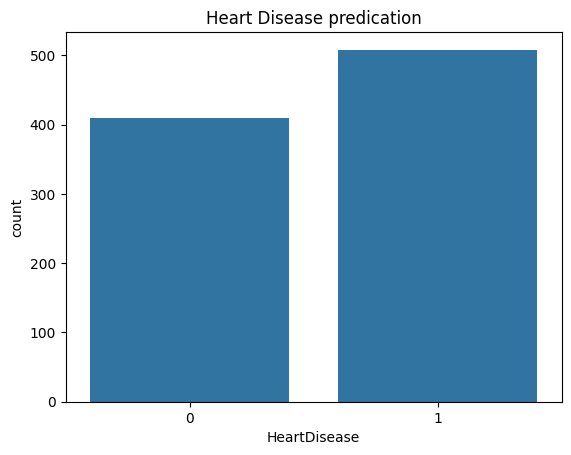

In [42]:
sns.countplot(x='HeartDisease',data=df)
plt.title("Heart Disease predication")
plt.show()

<Axes: >

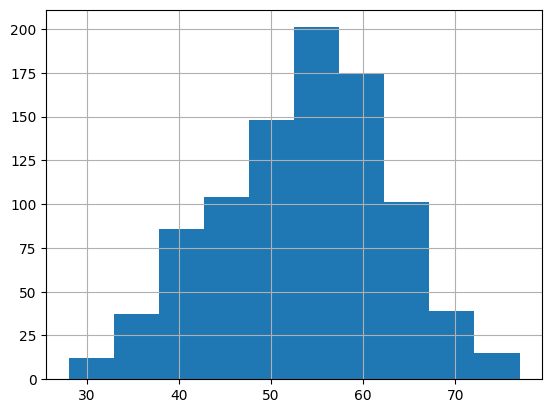

In [32]:
df['Age'].hist()

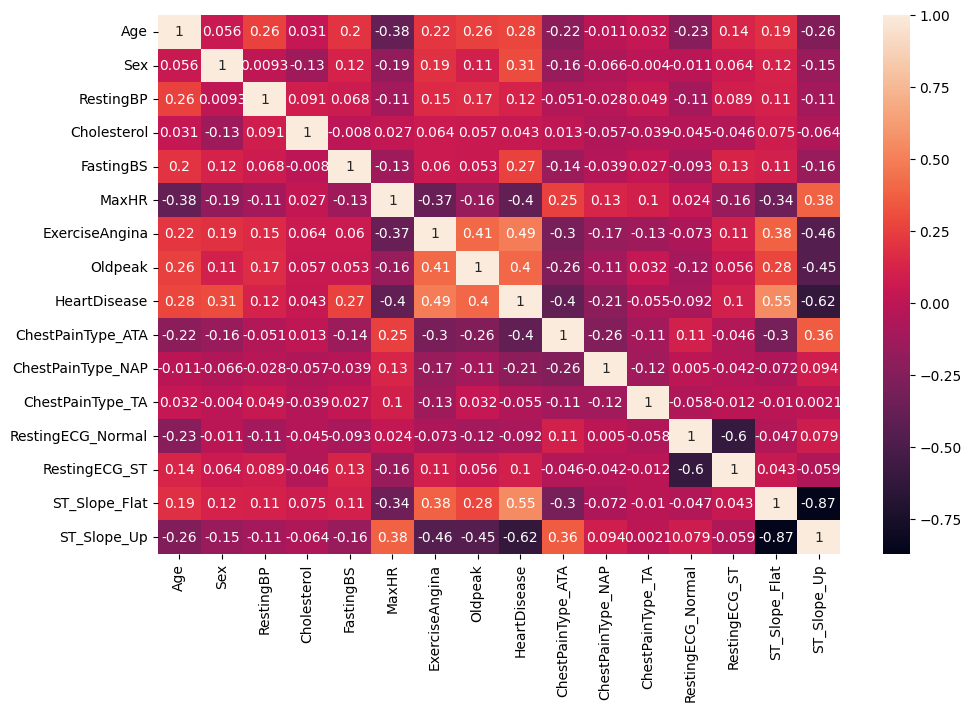

In [33]:
plt.figure(figsize=(11,7))
sns.heatmap(df.corr(),annot=True)
plt.show()

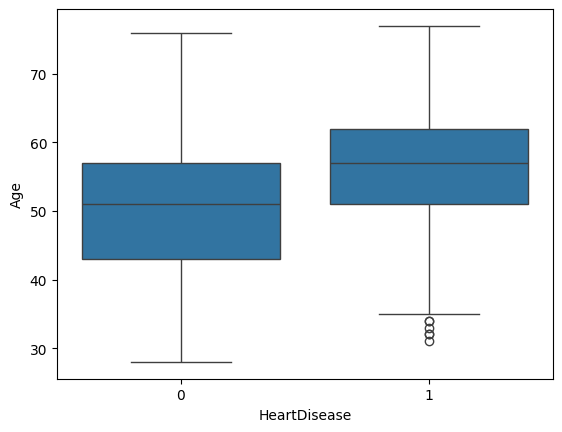

In [34]:
sns.boxplot(x='HeartDisease',y='Age',data=df)
plt.show()

Model Training


In [ ]:
model1=LogisticRegression( max_iter=2000,random_state=42)
model1.fit(x_train_scaler,y_train)
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

# Predictions
y_pred = model1.predict(x_test_scaler)

# Precision
precision = precision_score(y_test, y_pred)

# Recall
recall = recall_score(y_test, y_pred)

# F1 Score
f1 = f1_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# Full Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Precision: 0.8846153846153846
Recall: 0.9019607843137255
F1 Score: 0.8932038834951457

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.85      0.86        82
           1       0.88      0.90      0.89       102

    accuracy                           0.88       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.88      0.88      0.88       184



In [45]:
model2=RandomForestClassifier(
    n_estimators=150,
    max_depth=6,
    min_samples_split=10,
    random_state=42
)
model2.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [46]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,              
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

model.fit(x_train, y_train)

print("Train:", model.score(x_train, y_train))
print("Test :", model.score(x_test, y_test))

Train: 0.8841961852861036
Test : 0.842391304347826


In [48]:
print("Logistic Regression Accuracy:",model1.score(x_train_scaler,y_train))
print("Logistic Regression Accuracy:",model1.score(x_test,y_test))


Logistic Regression Accuracy: 0.8569482288828338
Logistic Regression Accuracy: 0.8804347826086957


In [49]:
print("Random Forest Accuracy:",model2.score(x_test,y_test))
print("Random Forest Accuracy:",model2.score(x_train,y_train))


Random Forest Accuracy: 0.8641304347826086
Random Forest Accuracy: 0.8950953678474114
